In [169]:
#project objective
#To clean, analyze, and visualize retail sales data in order to identify key drivers of revenue and profitability, understand customer purchasing behavior, evaluate pricing and discount strategies, and provide actionable business insights through interactive dashboards built in Python and Power BI.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [170]:
#loading the  sales dataset
df= pd.read_csv(r"C:\Users\LENOVO T480\Downloads\sales_project_June _23rd_2026\sales_project_June23rd_2025.csv")

In [171]:
#check first 10 rows
df.head(10)

,Unnamed: 0,customer_id,gender,age,email,phone_number,address,city,state,zip_code,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
0,0,2438,U,NaN,david547@hotmail.com,294-680-4916,4565 Maple Ln,San Antonio,GA,51693,...,DC,master,6539 Cedar Blvd,EXP,Cancelled,NaN,Yes,Online,NaN,640.9100000000001
1,1,3701,F,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.259999999999998
2,2,4648,FEMALE,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
3,3,3513,NaN,thirty,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,...,Cash,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN
4,4,3903,FEMALE,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.9499999999999
5,5,1009,Unknown,40+,sarah833@yahoo.com,986-579-1614,2061 Maple Ln,Houston,GA,19627,...,Cash,Mastercard,1088 Oak Ave,Pickup,delivered,good,no,Store B,NaN,412.9
6,6,1158,M,NaN,sarah929@yahoo.com,607-199-7796,Unknown,New York,OH,81753,...,DC,master,2387 Main St,Standard,Returned,2,yes,Website,NaN,7.819999999999993
7,7,1024,Unknown,NaN,invalid_email,157-580-2982,7690 Main St,Los Angeles,IL,63070,...,Debit Card,Amex,4361 Main St,Standard,Pending,3,Y,Store B,NaN,326.69000000000005
8,8,5930,F,NaN,lisa761@hotmail.com,298-488-1845,4496 Pine Rd,Phoenix,PA,0,...,paypal,VISA,5208 Cedar Blvd,Pickup,Shipped,10,No,Store A,NaN,NaN
9,9,2892,Male,NaN,david70@yahoo.com,985-540-1888,828 Main St,San Antonio,NY,58885,...,CC,Discover,7705 Pine Rd,Standard,PENDING,10,True,Store A,NaN,316.27000000000004


In [172]:
#describe the dataset
df.describe()

,Unnamed: 0,customer_id,zip_code,discount,cost
count,5250.000000,5250.000000,5250.00000,4717.000000,5250.000000
mean,2624.500000,3742.733143,50234.95619,0.201041,182.393044
std,1515.688787,1804.629212,29462.85263,0.114166,122.997360
min,0.000000,1001.000000,0.00000,0.000000,-10.000000
25%,1312.250000,2313.250000,26358.25000,0.100000,75.470000
50%,2624.500000,3625.500000,50641.50000,0.200000,182.025000
75%,3936.750000,4937.750000,75619.50000,0.300000,289.347500
max,5249.000000,10996.000000,99962.00000,0.400000,399.770000


In [173]:
#datasest information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             5250 non-null   int64  
 1   customer_id            5250 non-null   int64  
 2   gender                 4787 non-null   object 
 3   age                    3742 non-null   object 
 4   email                  5250 non-null   object 
 5   phone_number           5250 non-null   object 
 6   address                5250 non-null   object 
 7   city                   5250 non-null   object 
 8   state                  5250 non-null   object 
 9   zip_code               5250 non-null   int64  
 10  residence_type         4571 non-null   object 
 11  transaction_id         5250 non-null   object 
 12  transaction_date       5250 non-null   object 
 13  product_category       4781 non-null   object 
 14  product_name           5250 non-null   object 
 15  quan

In [174]:
#shape
df.shape

(5250, 30)

In [175]:
#drop duplicates
df=df.drop_duplicates()

In [176]:
#drop unnecessary columns
df.drop("Unnamed: 0", axis=1 , inplace=True)

In [177]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
0,2438,U,NaN,david547@hotmail.com,294-680-4916,4565 Maple Ln,San Antonio,GA,51693,With Parents,...,DC,master,6539 Cedar Blvd,EXP,Cancelled,NaN,Yes,Online,NaN,640.9100000000001
1,3701,F,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,Other,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.259999999999998
2,4648,FEMALE,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
3,3513,NaN,thirty,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Cash,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN
4,3903,FEMALE,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.9499999999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,4093,f,18-25,alex98@gmail.com,473-412-7823,1988 Cedar Blvd,San Antonio,PA,59861,Other,...,NaN,NaN,Same as billing,Overnight,Shipped,excellent,N,Store A,WELCOME20,391.36
5246,4773,Male,40+,lisa904@hotmail.com,123-456-7890,2926 Main St,Houston,CA,22237,OWN,...,Check,Discover,2271 Oak Ave,Pickup,NaN,good,False,NaN,NaN,108.44999999999999
5247,10649,M,25,lisa503@outlook.com,857-358-5600,4770 Oak Ave,Philadelphia,IL,0,Own,...,Cash,Amex,1898 Pine Rd,Pickup,Cancelled,4,no,Mobile App,FREESHIP,705.22
5248,8852,MALE,105,jane259@hotmail.com,774-233-6796,477 Cedar Blvd,New Yrok,IL,62678,OWN,...,paypal,VISA,5177 Oak Ave,Pickup,Pending,3,no,Store A,WELCOME20,38.110000000000014


In [178]:
#standardising gender column ,changing format of the text,  replacing values
df["gender"]= df["gender"].replace({'F': 'female',
                                    'f': 'female',
                                       'M': 'male',
                                       'U': np.nan,
                                       'Unknown': np.nan,
                                       ' ':np.nan})
                                       
#removing trailing spaces
df["gender"]= df["gender"].str.strip()
#standardising text format
df["gender"]= df["gender"].str.lower()
df["gender"]= df["gender"].str.title()

In [179]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
0,2438,NaN,NaN,david547@hotmail.com,294-680-4916,4565 Maple Ln,San Antonio,GA,51693,With Parents,...,DC,master,6539 Cedar Blvd,EXP,Cancelled,NaN,Yes,Online,NaN,640.9100000000001
1,3701,Female,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,Other,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.259999999999998
2,4648,Female,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
3,3513,NaN,thirty,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Cash,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN
4,3903,Female,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.9499999999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,4093,Female,18-25,alex98@gmail.com,473-412-7823,1988 Cedar Blvd,San Antonio,PA,59861,Other,...,NaN,NaN,Same as billing,Overnight,Shipped,excellent,N,Store A,WELCOME20,391.36
5246,4773,Male,40+,lisa904@hotmail.com,123-456-7890,2926 Main St,Houston,CA,22237,OWN,...,Check,Discover,2271 Oak Ave,Pickup,NaN,good,False,NaN,NaN,108.44999999999999
5247,10649,Male,25,lisa503@outlook.com,857-358-5600,4770 Oak Ave,Philadelphia,IL,0,Own,...,Cash,Amex,1898 Pine Rd,Pickup,Cancelled,4,no,Mobile App,FREESHIP,705.22
5248,8852,Male,105,jane259@hotmail.com,774-233-6796,477 Cedar Blvd,New Yrok,IL,62678,OWN,...,paypal,VISA,5177 Oak Ave,Pickup,Pending,3,no,Store A,WELCOME20,38.110000000000014


In [180]:
#standardising age column, replacing values and changing object type
df["age"].unique()

array([nan, '40+', 'thirty', '87', '58', '105', '18-25', '25', '62', '55',
       '88', '67', '16', '21', '86', '66', '30', '73', '65', '46', '22',
       '31', '51', '37', '43', '35', '84', '36', '48', '19', '85', '32',
       '82', '57', '77', '74', '39', '59', '71', '33', '90', '52', '27',
       '49', '53', '75', '81', '69', '41', '45', '20', '61', '29', '34',
       '79', '63', '15', '89', '78', '50', '26', '17', '28', '83', '54',
       '70', '23', '47', '44', '38', '76', '68', '40', '18', '24', '64',
       '56', '60', '80', '72', '42'], dtype=object)

In [181]:
df["age"]=df["age"].replace({'40+':np.nan,
                             'thirty':30,
                             '18-25': np.nan,
                             '105': np.nan,
                             ' ': np.nan})
df["age"]=pd.to_numeric(df["age"], errors='coerce')


In [182]:
df["age"]

0        NaN
1        NaN
2       30.0
3       30.0
4       87.0
        ... 
5245     NaN
5246     NaN
5247    25.0
5248     NaN
5249     NaN
Name: age, Length: 5250, dtype: float64

In [183]:
#drop null
df.dropna(subset="age", inplace=True)

In [184]:
#categorizing data
def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 18:
        return 'Child'
    elif age <= 35:
        return 'Youth'
    elif age <= 50:
        return 'Middle age'
    else:
        return 'Elderly'

# Apply the function to create the new column
df['age_groups'] = df['age'].apply(categorize_age)

In [185]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit,age_groups
2,4648,Female,30.0,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13,Youth
3,3513,NaN,30.0,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN,Youth
4,3903,Female,87.0,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.9499999999999,Elderly
10,1228,Female,58.0,alex859@outlook.com,143-676-5344,5332 Main St,San Diego,PA,94122,NaN,...,Amex,5920 Pine Rd,EXP,Returned,1,Y,NaN,NaN,-63.369999999999976,Elderly
13,3532,Male,30.0,mike151@gmail.com,316-123-5676,7170 Cedar Blvd,Philadelphia,TX,89429,With Parents,...,Amex,4854 Oak Ave,Overnight,Shipped,2,Y,Store A,InvalidCode,224.13,Youth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5240,3920,Male,25.0,sarah332@hotmail.com,123-456-7890,9928 Oak Ave,San Diego,NC,32949,Lease,...,Mastercard,2445 Maple Ln,Pickup,Pending,excellent,Y,Mobile App,NaN,-362.58,Youth
5241,4172,NaN,30.0,mike711@gmail.com,375-136-7246,3218 Maple Ln,New Yrok,OH,71563,Other,...,Mastercard,4722 Pine Rd,Overnight,PENDING,NaN,Y,Online,NaN,-243.89999999999998,Youth
5243,5427,Female,75.0,alex853@gmail.com,121-923-3695,6150 Cedar Blvd,San Diego,NY,21643,With Parents,...,VISA,7017 Maple Ln,NaN,Cancelled,0,NaN,NaN,NaN,NaN,Elderly
5244,1467,Female,47.0,david165@outlook.com,123-456-7890,425 Cedar Blvd,Chicago,NC,91379,rent,...,Discover,7678 Cedar Blvd,NaN,Returned,1,NaN,store a,NaN,-121.47999999999999,Middle age


In [186]:
#removing invalid emails
df["email"]=df["email"].replace({"invalid_email": np.nan})

In [187]:
#standardising city and replace values
df["city"].unique()

array(['Chicago', 'Houston', 'San Antonio', 'San Diego', 'Philadelphia',
       'Phoenix', 'New Yrok', 'New York', 'Los Angeles'], dtype=object)

In [188]:
df["city"]=df["city"].replace({'New Yrok':'New York',
                               ' ':np.nan})
df["city"]=df["city"].str.lower()
df["city"]=df["city"].str.title()

In [189]:
df


,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit,age_groups
2,4648,Female,30.0,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13,Youth
3,3513,NaN,30.0,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN,Youth
4,3903,Female,87.0,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.9499999999999,Elderly
10,1228,Female,58.0,alex859@outlook.com,143-676-5344,5332 Main St,San Diego,PA,94122,NaN,...,Amex,5920 Pine Rd,EXP,Returned,1,Y,NaN,NaN,-63.369999999999976,Elderly
13,3532,Male,30.0,mike151@gmail.com,316-123-5676,7170 Cedar Blvd,Philadelphia,TX,89429,With Parents,...,Amex,4854 Oak Ave,Overnight,Shipped,2,Y,Store A,InvalidCode,224.13,Youth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5240,3920,Male,25.0,sarah332@hotmail.com,123-456-7890,9928 Oak Ave,San Diego,NC,32949,Lease,...,Mastercard,2445 Maple Ln,Pickup,Pending,excellent,Y,Mobile App,NaN,-362.58,Youth
5241,4172,NaN,30.0,mike711@gmail.com,375-136-7246,3218 Maple Ln,New York,OH,71563,Other,...,Mastercard,4722 Pine Rd,Overnight,PENDING,NaN,Y,Online,NaN,-243.89999999999998,Youth
5243,5427,Female,75.0,alex853@gmail.com,121-923-3695,6150 Cedar Blvd,San Diego,NY,21643,With Parents,...,VISA,7017 Maple Ln,NaN,Cancelled,0,NaN,NaN,NaN,NaN,Elderly
5244,1467,Female,47.0,david165@outlook.com,123-456-7890,425 Cedar Blvd,Chicago,NC,91379,rent,...,Discover,7678 Cedar Blvd,NaN,Returned,1,NaN,store a,NaN,-121.47999999999999,Middle age


In [190]:
#standardising product_category
df["product_category"].unique()

array(['Cloth', 'Toys', nan, 'Home', 'Books', 'Unknown', 'Sports',
       'Clothing', 'Electronics', 'Electrnics', 'Beauty'], dtype=object)

In [191]:
df["product_category"]=df["product_category"].replace({'Cloth':'Clothing',
                                                       'Electrnics':'Electronics',
                                                       'Unknown':np.nan,
                                                       'nan': np.nan})

In [192]:
#standardising quantity column
df["quantity"].unique()

array(['1', '-1', '3', '10', nan, 'one', '0', 'two', '4', 'three', '5',
       '2', '100'], dtype=object)

In [193]:
df["quantity"]=df["quantity"].replace({'-1':np.nan,
                                       0:np.nan,
                                       'one':1,
                                       'two':2,
                                       'three': 3})

In [194]:
#make a new column gross sales
df["quantity"]=pd.to_numeric(df["quantity"],errors="coerce")
df["unit_price"]=pd.to_numeric(df["unit_price"],errors="coerce")
df["gross_sales"]=df["quantity"]*df["unit_price"]

In [195]:
#fixing the revenue column with accurate values
#Revenue=(Unit Price×Quantity)×(1−Discount)
df["revenue"]=df["gross_sales"]*(1-df["discount"])

In [196]:
df["revenue"]

2        362.5391
3             NaN
4             NaN
10      1716.4400
13            NaN
          ...    
5240     908.6286
5241     220.6239
5243          NaN
5244       0.0000
5247    2153.6220
Name: revenue, Length: 1836, dtype: float64

In [197]:
#fixing the profit column
#profit= revenue-cost
df["profit"]=df["revenue"]-df["cost"]

In [198]:
df["profit"]

2        170.1491
3             NaN
4             NaN
10      1412.3000
13            NaN
          ...    
5240     525.0986
5241     -69.4561
5243          NaN
5244    -271.1900
5247    2090.0120
Name: profit, Length: 1836, dtype: float64

In [199]:
#standardising shipping_method column formatting texts
df["shipping_method"]=df["shipping_method"].replace({"EXP":"Express",
                                                     ' ':np.nan})

In [200]:
df["shipping_method"]=df["shipping_method"].str.lower()
df["shipping_method"]=df["shipping_method"].str.title()

In [201]:
#standardising delivery_status and formatting texts
df["delivery_status"]=df["delivery_status"].str.lower()
df["delivery_status"]=df["delivery_status"].str.title()


In [202]:
#standardising returned_item and formatting text
df["returned_item"].unique()

array(['False', 'N', 'no', 'Y', nan, 'Yes', 'No', 'True', 'yes'],
      dtype=object)

In [203]:
df["returned_item"]=df["returned_item"].replace({"Y":"True",
                                                 "yes":"True",
                                                 "Yes":"True",
                                                 "N":"False",
                                                 "No":"False",
                                                 "no":"False"})
                                                 
    

In [204]:
df["returned_item"]=df["returned_item"].str.lower()
df["returned_item"]=df["returned_item"].str.title()

In [205]:
df["returned_item"].unique()

array(['False', 'True', nan], dtype=object)

In [206]:
#standardise and extract month and year from transaction_date
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed')
df['month'] = df['transaction_date'].dt.month_name()
df['month_number'] = df['transaction_date'].dt.month
df['year'] = df['transaction_date'].dt.year

In [207]:
#create discount_price column
df["discount_ammount"]=df["gross_sales"]-df["revenue"]

In [208]:
#create profit mirgin column
df["profit_mirgin"]=(df["profit"]/df["revenue"])*100

In [209]:
df.drop(["customer_satisfaction","store_location","promo_code_used"],axis=1, inplace=True)

In [210]:
df=df.dropna()

In [211]:
df=df.reset_index(drop=True)

In [212]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,delivery_status,returned_item,profit,age_groups,gross_sales,month,month_number,year,discount_ammount,profit_mirgin
0,4648,Female,30.0,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,Shipped,False,170.1491,Youth,470.83,November,11,2025,108.2909,46.932621
1,1466,Female,30.0,david860@outlook.com,997-600-8649,9792 Cedar Blvd,Philadelphia,GA,87456,With Parents,...,Pending,True,-97.7726,Youth,282.51,November,11,2025,73.4526,-46.768304
2,2224,Female,30.0,alex40@outlook.com,473-921-4406,5934 Cedar Blvd,Philadelphia,PA,58622,OWN,...,Shipped,False,500.3755,Youth,822.15,March,3,2025,24.6645,62.744150
3,5294,Female,66.0,emma243@outlook.com,123-456-7890,8485 Pine Rd,Phoenix,MI,72819,Lease,...,Delivered,True,175.0080,Elderly,314.45,January,1,2026,50.3120,66.256275
4,2481,Male,25.0,sarah32@hotmail.com,340-154-9102,9588 Maple Ln,Los Angeles,OH,71385,Lease,...,Delivered,True,46.9586,Youth,275.66,May,5,2025,79.9414,23.992916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,2077,Female,25.0,alex29@gmail.com,532-164-7956,4768 Cedar Blvd,Philadelphia,CA,56482,Rent,...,Pending,False,-28.4700,Youth,0.00,July,7,2024,0.0000,-inf
313,2956,Male,37.0,jane586@gmail.com,123-456-7890,Unknown,San Diego,OH,31822,Other,...,Delivered,True,66.5689,Middle age,291.47,April,4,2026,37.8911,26.251750
314,2807,Female,30.0,david400@hotmail.com,215-276-1984,5166 Pine Rd,San Diego,NC,89506,Rent,...,Delivered,True,-185.2825,Youth,258.93,August,8,2024,64.7325,-95.409313
315,6023,Female,30.0,sarah148@hotmail.com,958-845-9119,610 Maple Ln,New York,PA,47916,OWN,...,Delivered,True,1052.1250,Youth,1552.25,March,3,2026,155.2250,75.311823


In [214]:
#convert it to csv
df.to_csv(r"C:\Users\LENOVO T480\Downloads\clean_sales_june_23_dtataset\clean.csv")

Text(0.5, 1.0, 'PROFIT PER PRODUCT CATEGORY')

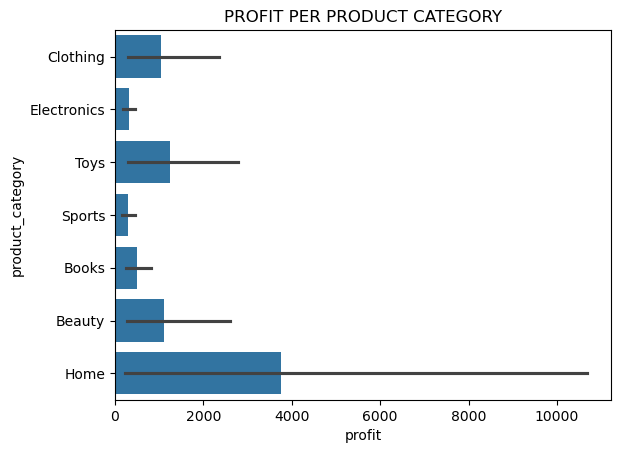

In [216]:
#visualizations
#1.Which categories generate the highest revenue and profit?
sns.barplot(data=df,
            x='profit',
            y='product_category')
plt.title("PROFIT PER PRODUCT CATEGORY")

<Axes: xlabel='discount', ylabel='profit'>

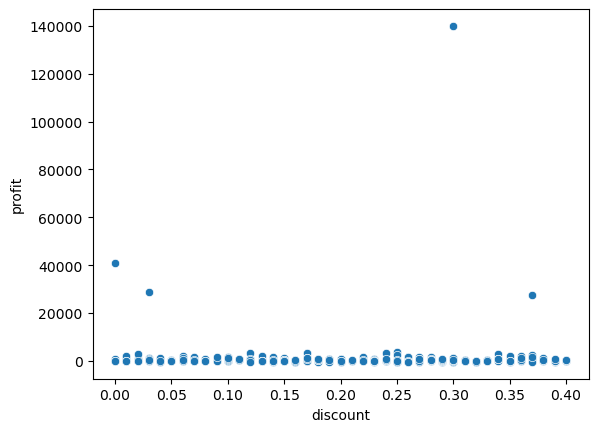

In [217]:
#2.How does discount affect revenue and profit?
sns.scatterplot(
    data=df,
    x='discount',
    y='profit')

In [ ]:
#larger discounts do not reduce profit

Text(0.5, 1.0, 'Revenue Per Age_Group')

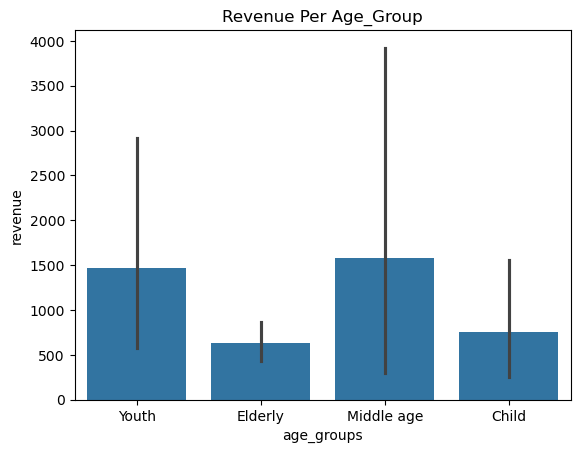

In [219]:
#3.Which customer age groups spend the most?
sns.barplot(data=df,
            x="age_groups",
            y="revenue")
plt.title("Revenue Per Age_Group")

In [ ]:
#The middle age spend the most on the products sold in the supermarket. They are closely followed y the youth while the elderly spend the least.
#Product advertisement should be aimed at encouraging the elderly to buy more.


Text(0.5, 1.0, 'Revenue Per City')

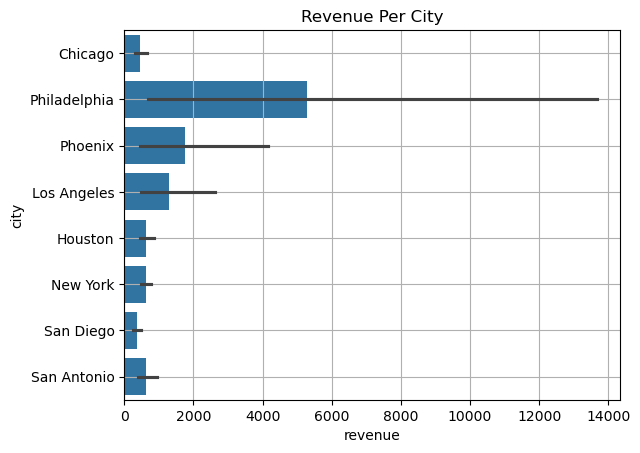

In [230]:
#4.Which cities generate the most income?

sns.barplot(data=df,
            x="revenue",
            y="city")
plt.grid()
plt.title("Revenue Per City")


In [ ]:
#Philadelphia rank first

Text(0.5, 1.0, 'Revenue Per Product')

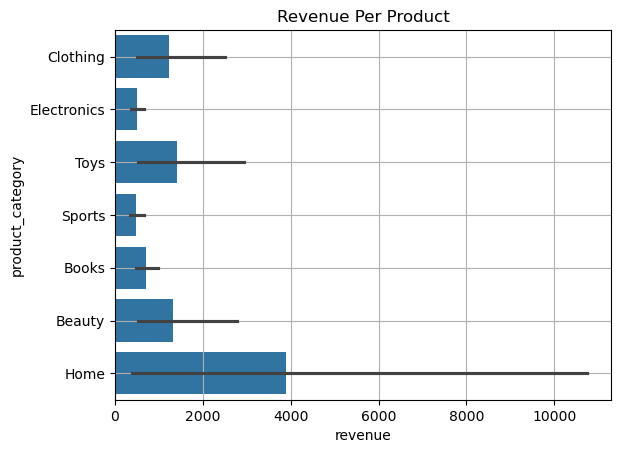

In [231]:
#5. Which products are the most profitable?

sns.barplot(data=df,
            x="revenue",
            y="product_category")
plt.grid()
plt.title("Revenue Per Product")

Text(0.5, 1.0, 'Revenue Per Payment_Category')

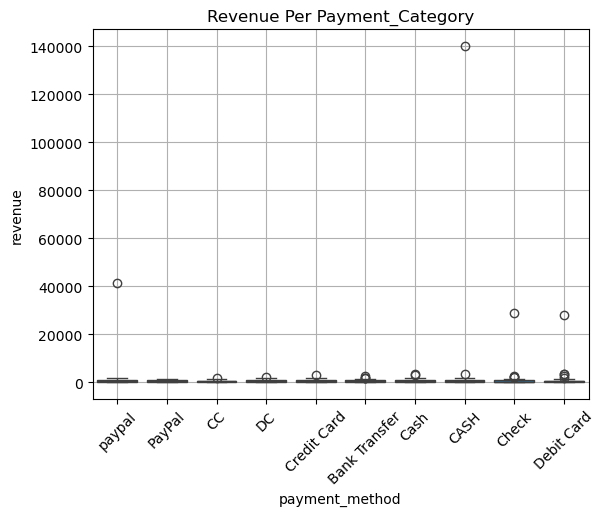

In [229]:
#6. which payment methods generate higher-value purchases
sns.boxplot(
    data=df,
    x='payment_method',
    y='revenue'
)
plt.grid()
plt.xticks(rotation=45)
plt.title("Revenue Per Payment_Category")


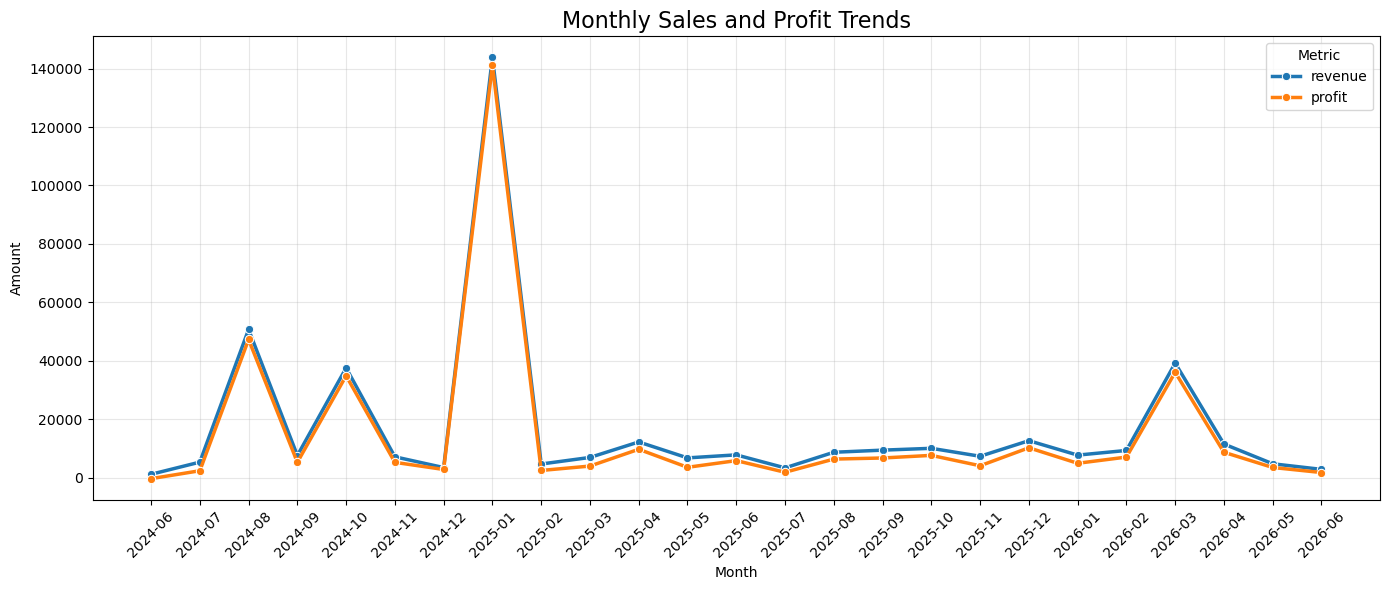

In [232]:
#7.Monthly Sales Profit trend
df['year_month'] = pd.to_datetime(df['transaction_date']).dt.to_period('M').astype(str)
monthly_sales = (
    df.groupby('year_month', as_index=False)
      .agg({
          'revenue':'sum',
          'profit':'sum'
      })
)

monthly_sales = monthly_sales.melt(
    id_vars='year_month',
    value_vars=['revenue','profit'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x='year_month',
    y='Amount',
    hue='Metric',
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Sales and Profit Trends', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Axes: >

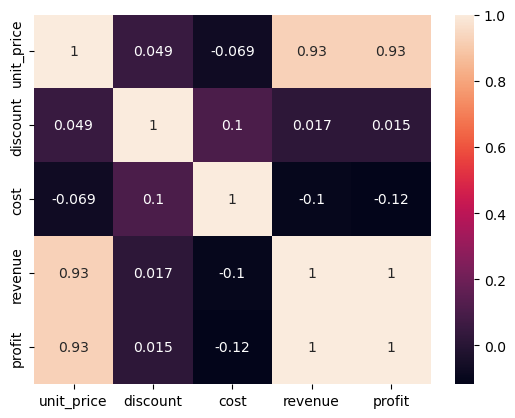

In [233]:
#8.Relationship among unit price, discount, cost, Revenue and profit
sns.heatmap(
    df[
      ['unit_price',
       'discount',
       'cost',
       'revenue',
       'profit']
    ].corr(),
    annot=True
)